**Naive Bayes Classifier**

This program performs spam email detection using Naive Bayes Classifier.

Note: Please change the file directories before running the code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt  # For visualization
import os   # For handling of the file directories 


"""
        PRELIMINARIES.
        Read and open the data then organize them into Pandas dataframe. Note: Please change the file directories before running the code.
        Then, split the data into training and test sets.
"""


# Directory of file containing the labels (Please change this to the directory of the file "labels" in your computer)
file_dir_labels = r"C:\Users\Reign\Desktop\AI 201\Naive Bayes Classifier\AI201_PA2_Spam_Filter_1SAY24-25\trec06p-ai201\trec06p-ai201\labels"   

# Open the file containing the labels
file_labels = []
with open(file_dir_labels, "r") as file:
    for line in file:
        label, others = line.strip().split()
        file_labels.append(label)
file_labels = file_labels[:round(1.0*len(file_labels))] 

 # Root directory containing the data (Please change this to the directory of the folder "data" in your computer)
file_dir_data = r"C:\Users\Reign\Desktop\AI 201\Naive Bayes Classifier\AI201_PA2_Spam_Filter_1SAY24-25\trec06p-ai201\trec06p-ai201\data"  

# Iterate over all the files in the folder then save directories into a list
emails_dirs = []
for subdir, dirs, files in os.walk(file_dir_data):
    for file in files:
       emails_dirs.append(os.path.join(subdir, file))
emails_dirs.pop(0) # Disregard the "DS_Store" file
emails_dirs = emails_dirs[:round(1.0*len(emails_dirs))]

# Split the data in the "emails" list into training and testing sets
# Assume that the data is already randomized (spam and ham)
split = 0.70
train = emails_dirs[:round(split*len(emails_dirs))]  # First 70%
test = emails_dirs[round(split*len(emails_dirs)):]   # Latter 30%

# Split the labels into training and testing sets as well
labels_train = file_labels[:round(split*len(file_labels))]
labels_test = file_labels[round(split*len(file_labels)):]

# Open the emails and add them into a list
emails_train = []
for email in train:
    open_email = open(email, encoding = "utf-8", errors = "ignore").read()
    emails_train.append(open_email)
    
emails_test = []
for email in test:
    open_email = open(email, encoding = "utf-8", errors = "ignore").read()
    emails_test.append(open_email)

# Clean the dataset by getting only the actual words
def Clean(email):
    """
        Function that cleans the data by getting only the actual words in the emails.
        Input: Email (list)
        Output: Cleaned email (list)
    """
    emails = email.split()
    words = []
    for word in emails:
        if word.isalpha() == True:
            words.append(word)
    return words

cleaned_emails_train = []
for email in emails_train:
    cleaned_emails_train.append(Clean(email))

cleaned_emails_test = []
for email in emails_test:
    cleaned_emails_test.append(Clean(email))

# Organize the labels and corresponding emails into a dictionary
#data_train = {"Labels": labels_train, "Train": cleaned_emails_train}
#data_test = {"Labels": labels_test, "Test": cleaned_emails_test}


"""
        VOCABULARY.
        Iterate over each word (string) in the email and get only the word (string) containing letters.
        Then, get the words in spam and ham emails and count them.
"""

# Get only the words from the cleaned emails
vocabulary = []
for email in cleaned_emails_train:
    for word in email:
        vocabulary.append(word)

vocabulary = list(set(vocabulary))  # set() to ensure we get only the unique words

# Length of the vocabulary
N_vocabulary = len(vocabulary)

# Get the index of the spam and ham emails
index_spam = []
index_ham = []

for index, label in enumerate(labels_train):
    if label == "spam":
        index_spam.append(index)
    if label == "ham":
        index_ham.append(index)

# Get the spam and ham emails in the training set
spam_emails_train = [cleaned_emails_train[index] for index in index_spam]
ham_emails_train = [cleaned_emails_train[index] for index in index_ham]

words_in_spam = []
for email in spam_emails_train:
    for word in email:
        words_in_spam.append(word)
words_in_spam = list(set(words_in_spam))  # To also get unique words in spam emails, implies count = 1 if it occurs in spam, this shortens run time

words_in_ham = []
for email in ham_emails_train:
    for word in email:
        words_in_ham.append(word)
words_in_ham = list(set(words_in_ham))  # To also get unique words in ham emails, implies count = 1 if it occurs in ham, this shortens run time

# Create a dictionary to store the number of times the word in the vocabulary occured in either spam or ham emails
# Count of the word = 0 if it is not in spam/ham
count_word_spam = {word: 0 for word in vocabulary}
count_word_ham = {word: 0 for word in vocabulary}

for word in vocabulary:
    if word in words_in_spam:
        count_word_spam[word] += 1
    if word in words_in_ham:
        count_word_ham[word] += 1

Prior probabilities of the training set:
Spam: 0.6530311614730878
Ham: 0.3469688385269122


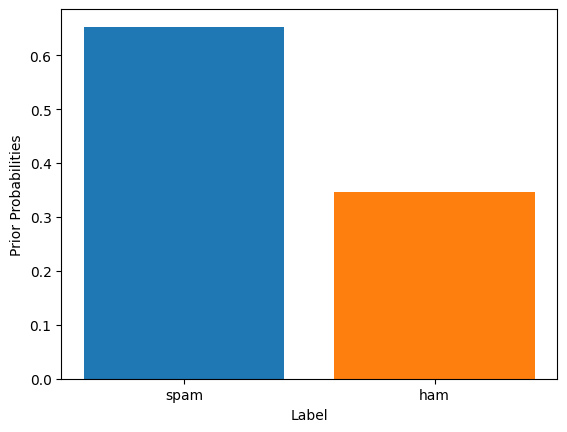

In [2]:
"""
        CALCULATE THE PRIORS.
        Calculate the prior probabilities (whether spam or ham) of the training set
        
"""

# Calculate priors
P_spam = len(spam_emails_train) / len(cleaned_emails_train)
P_ham = len(ham_emails_train) / len(cleaned_emails_train)

print("Prior probabilities of the training set:")
print("Spam:", P_spam)
print("Ham:", P_ham)

# Plot the priors to visualize
x = ["spam", "ham"]
y = [P_spam, P_ham]
plt.bar(x, y, color = ["tab:blue", "tab:orange"])
plt.xlabel("Label")
plt.ylabel("Prior Probabilities")
#plt.savefig(r"C:\Users\Reign\Desktop\AI 201\Naive Bayes Classifier\priors_100.png")  # Save the figure
plt.show()

In [3]:
"""
        CLASSIFICATION.
        Calculate the probabilities of the document being spam or ham and classify them.
        Apply Lambda smoothing using different values.
"""

# Create a function to classify according to Naive Baye's Theorem
def Classify(email, Lambda):
    """
        Function that classifies the email as spam or ham according to Naive Baye's Classification Theory.
        Input: Email (list), Lambda value (float)
        Output: Classification (string)
    """

    # Get only the actual words
    words_in_email = []
    for word in email:
        words_in_email.append(word)
            
    # Initialize the probabilities        
    P_spam_email = np.log(P_spam)
    P_ham_email = np.log(P_ham)

    # Iterate over all the words in the test email and check their counts according to the spam or ham dictionary
    for word in words_in_email:
        if word in count_word_spam:
            P_spam_email += np.log((count_word_spam[word] + Lambda) / (len(spam_emails_train) + Lambda*N_vocabulary))
            
        if word in count_word_ham:
            P_ham_email += np.log((count_word_ham[word] + Lambda) / (len(ham_emails_train) + Lambda*N_vocabulary))
    
    # Classification      
    if P_spam_email > P_ham_email:
        return "spam"
    elif P_spam_email < P_ham_email:
        return "ham"
    else:
        return "Inconclusive."


"""
        CALCULATE PRECISION AND RECALL.
        Calculate the precision and recall of the Naive Baye's Classifier for evaluation.
"""

def Evaluate(classification):
    """
        Function that calculates the precision and recall of the classifier.
        Input: list of classification
        Output: Precision and Recall values
    """
    labels = labels_test

    TP = 0
    FP = 0
    TN = 0
    FN = 0
    for i in range(len(classification)):
        if labels[i] == "spam" and classification[i] == "spam":
            TP += 1
        elif labels[i] == "ham" and classification[i] == "spam":
            FP += 1
        elif labels[i] == "ham" and classification[i] == "ham":
            TN += 1
        elif labels[i] == "spam" and classification[i] == "ham":
            FN += 1

    Precision = TP / (TP + FP)
    Recall = TP / (TP + FN)
    F1 = 2*(Precision*Recall) / (Precision + Recall)
    return Precision, Recall, F1

Classify the test emails with variations on the value of Lambda for smoothing. We also calculate the precision and recall of the results corresponding to the different Lambda values and plot them for comparison.

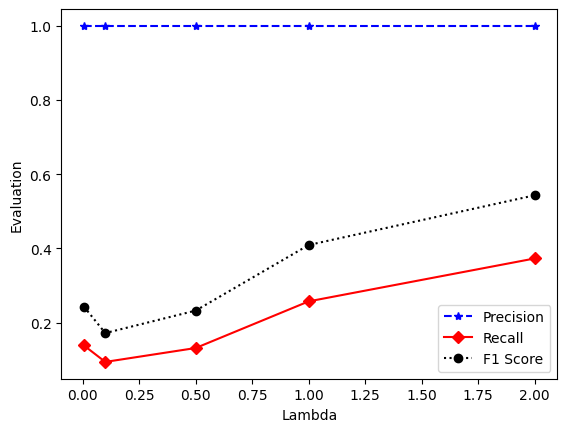

In [4]:
Lambda = [0.005, 0.1, 0.5, 1.0, 2.0]
Precision = []
Recall = []
F1 = []

range_test = int(len(cleaned_emails_test))
# Classify the test set with Lambda = 0.005
Lambda_0_005_classification = []
for i in range(range_test):
    Lambda_0_005_classification.append(Classify(cleaned_emails_test[i], 0.005))

precision_Lambda_0_005, recall_Lambda_0_005, f1_Lambda_0_005 = Evaluate(Lambda_0_005_classification)
Precision.append(precision_Lambda_0_005)
Recall.append(recall_Lambda_0_005)
F1.append(f1_Lambda_0_005)

# Classify the test set with Lambda = 0.1
Lambda_0_1_classification = []
for i in range(range_test):
    Lambda_0_1_classification.append(Classify(cleaned_emails_test[i], 0.1))

precision_Lambda_0_1, recall_Lambda_0_1, f1_Lambda_0_1 = Evaluate(Lambda_0_1_classification)
Precision.append(precision_Lambda_0_1)
Recall.append(recall_Lambda_0_1)
F1.append(f1_Lambda_0_1)

# Classify the test set with Lambda = 0.5
Lambda_0_5_classification = []
for i in range(range_test):
    Lambda_0_5_classification.append(Classify(cleaned_emails_test[i], 0.5))

precision_Lambda_0_5, recall_Lambda_0_5, f1_Lambda_0_5 = Evaluate(Lambda_0_5_classification)
Precision.append(precision_Lambda_0_5)
Recall.append(recall_Lambda_0_5)
F1.append(f1_Lambda_0_5)

# Classify the test set with Lambda = 1.0
Lambda_1_classification = []
for i in range(range_test):
    Lambda_1_classification.append(Classify(cleaned_emails_test[i], 1.0))

precision_Lambda_1, recall_Lambda_1, f1_Lambda_1 = Evaluate(Lambda_1_classification)
Precision.append(precision_Lambda_1)
Recall.append(recall_Lambda_1)
F1.append(f1_Lambda_1)

# Classify the test set with Lambda = 2.0
Lambda_2_classification = []
for i in range(range_test):
    Lambda_2_classification.append(Classify(cleaned_emails_test[i], 2.0))

precision_Lambda_2, recall_Lambda_2, f1_Lambda_2 = Evaluate(Lambda_2_classification)
Precision.append(precision_Lambda_2)
Recall.append(recall_Lambda_2)
F1.append(f1_Lambda_2)

# Plot the Precision and Recall of varying Lambda
plt.plot(Lambda, Precision, "--b*", label = "Precision")
plt.plot(Lambda, Recall, "-rD", label = "Recall")
plt.plot(Lambda, F1, "o:k", label = "F1 Score")
plt.xlabel("Lambda")
plt.ylabel("Evaluation")
plt.legend()
#plt.savefig(r"C:\Users\Reign\Desktop\AI 201\Naive Bayes Classifier\precision+recall_100.png")  # Save the figure
plt.show()

Applying Hovold's method of getting the most informative words, thereby reducing the vocabulary to 200 words.

In [5]:
# Get the frequency of each word in the spam and ham emails
freq_word = {word: 0 for word in vocabulary}

for word in vocabulary:
    if word in words_in_spam:
        freq_word[word] += 1
    if word in words_in_ham:
        freq_word[word] += 1

# Calculate the mutual information according to the equation in Hovold's paper
mutual_info = {word: 0 for word in vocabulary}

for word, freq in freq_word.items():
    prob_spam = freq / len(words_in_spam)  # Probability of the word being in a spam document
    prob_ham = freq / len(words_in_ham)    # Probability of the word being in a ham document
    mutual_info[word] = (prob_spam*np.log2(prob_spam / (prob_ham*P_spam))) + (prob_ham*np.log2(prob_ham / (prob_spam*P_ham)))  

# Sort and rank the words
new_vocab_list = dict(sorted(mutual_info.items(), key = lambda x:x[1], reverse = True))

new_vocab = []

for word in new_vocab_list:
    new_vocab.append(word)

vocabulary = new_vocab[:200]
N_vocabulary = len(vocabulary)

# Print the new vocabulary
print("New vocabulary:")
print(vocabulary)

# Use Lambda = best
Lambda_new_vocab = []
for i in range(range_test):
    Lambda_new_vocab.append(Classify(cleaned_emails_test[i], 2.0))

New vocabulary:
['cone', 'Research', 'Nicole', 'Confirm', 'germ', 'pulling', 'Clarence', 'offend', 'Previously', 'Shared', 'Agencies', 'via', 'mark', 'referring', 'World', 'PRINTER', 'Multicultural', 'programme', 'streets', 'primarily', 'PO', 'air', 'fish', 'total', 'counsel', 'stymie', 'cocktail', 'amateur', 'kathy', 'media', 'Number', 'Tabs', 'robbed', 'propagates', 'HDD', 'iPlanet', 'IDEA', 'pans', 'incessant', 'inserted', 'defective', 'enrolling', 'galaxy', 'harass', 'Standish', 'perusal', 'protector', 'seventy', 'Sir', 'BEGIN', 'Could', 'Option', 'focuses', 'pit', 'days', 'Presley', 'noWrap', 'vaughn', 'e', 'Keeping', 'Hospital', 'brigade', 'resistant', 'drop', 'fortress', 'plate', 'aloud', 'Contractor', 'charged', 'consideration', 'Maxwell', 'including', 'Journal', 'cool', 'pluck', 'strangers', 'effectiveness', 'receipt', 'none', 'allow', 'armed', 'RI', 'reasonable', 'II', 'Returns', 'corporate', 'level', 'contextual', 'worthy', 'Wizard', 'lookin', 'credit', 'hammers', 'WEST', 'i

In [6]:
# Evaluate the modified classifier by obtaining TP, FP, TN, and FN
TP = 0
FP = 0
TN = 0
FN = 0

for i in range(len(Lambda_new_vocab)):
    if labels_test[i] == "spam" and Lambda_new_vocab[i] == "spam":
        TP += 1
    if labels_test[i] == "ham" and Lambda_new_vocab[i] == "spam":
        FP += 1
    if labels_test[i] == "ham" and Lambda_new_vocab[i] == "ham":
        TN += 1
    if labels_test[i] == "spam" and Lambda_new_vocab[i] == "ham":
        FN += 1

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

TP: 0
FP: 0
TN: 3724
FN: 7623
